# Modifying a Problem with pyRDDLGym

In this notebook, we show the correct way to modify a RDDL problem description programmatically.

First, install the required packages:

In [1]:
%pip install --quiet --upgrade pip
%pip install --quiet pyRDDLGym rddlrepository

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Next, import the required packages:

In [1]:
import pyRDDLGym

We will load the CartPole control environment:

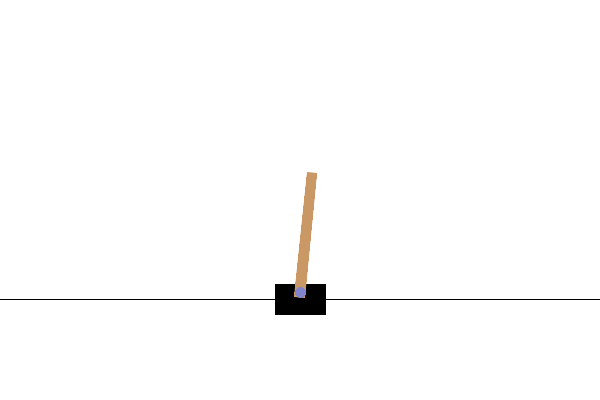

In [2]:
env = pyRDDLGym.make('CartPole_Continuous_gym', '0')
state, _ = env.reset()
env.render()

Let us double the length of the pole, flip the initial angular position of the pole and shift the initial cart position:

In [3]:
env.model.non_fluents['POLE-LEN'] = 1.0
env.model.state_fluents['ang-pos'] = -0.1
env.model.state_fluents['pos'] = 0.5

However, this will not update the environment instance, due to non-fluent baked into the compilation. Instead, we can recreate the environment using the ``make()`` command, passing the model as domain:

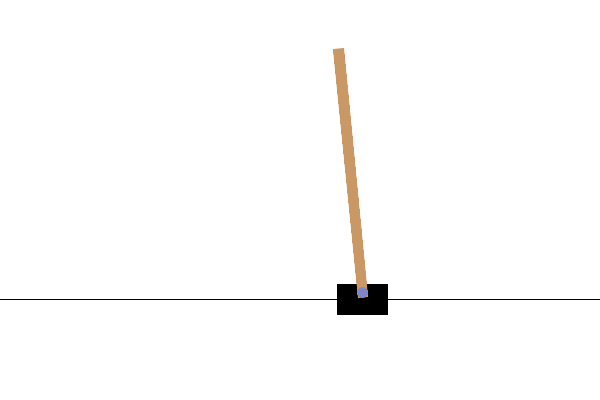

In [5]:
new_env = pyRDDLGym.make(env.model, instance=None)
new_env.set_visualizer(env._visualizer.__class__)

state, _ = new_env.reset()
new_env.render()